c:\Users\yuriy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 8.56k/8.56k [00:00<00:00, 15.7MB/s]

Extracting files...
Path to dataset files: C:\Users\yuriy\.cache\kagglehub\datasets\fedesoriano\heart-failure-prediction\versions\1

Dataset Head:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 918 en

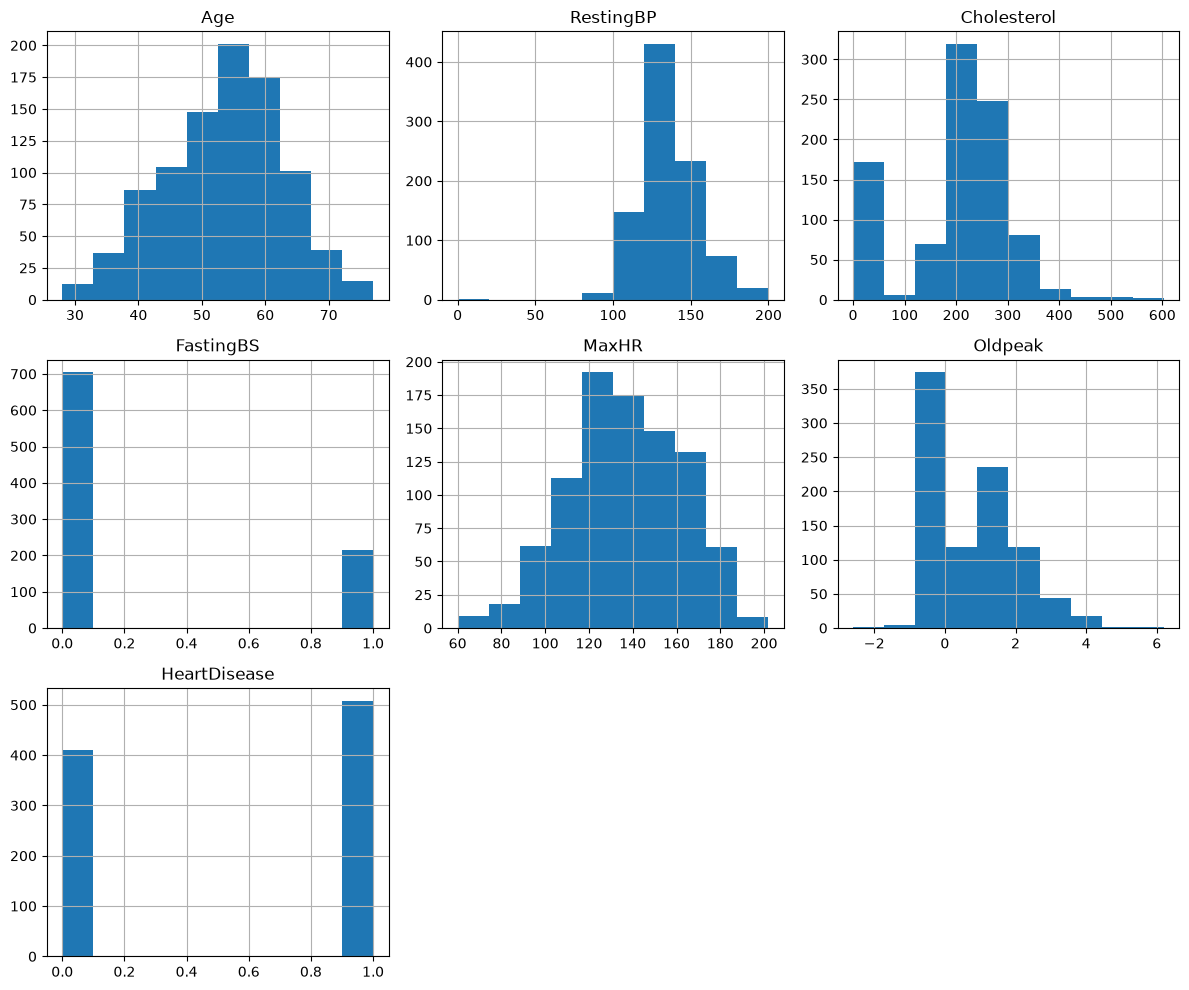

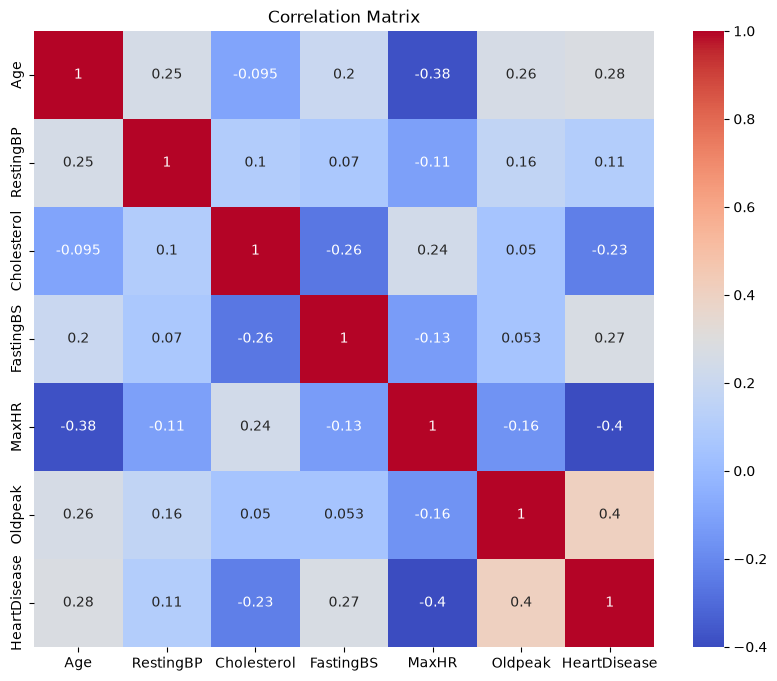

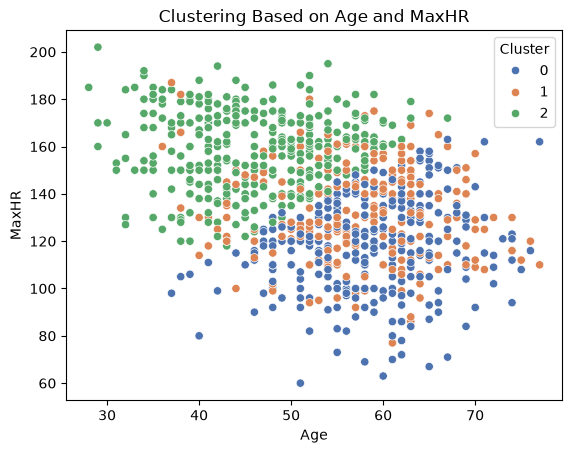

C:\Users\yuriy\AppData\Local\Temp\ipykernel_23784\2200094112.py:75: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns



Logistic Regression Results
Accuracy: 0.8768115942028986
[[100  12]
 [ 22 142]]
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       112
           1       0.92      0.87      0.89       164

    accuracy                           0.88       276
   macro avg       0.87      0.88      0.87       276
weighted avg       0.88      0.88      0.88       276


Decision Tree Results
Accuracy: 0.7753623188405797
[[ 94  18]
 [ 44 120]]
              precision    recall  f1-score   support

           0       0.68      0.84      0.75       112
           1       0.87      0.73      0.79       164

    accuracy                           0.78       276
   macro avg       0.78      0.79      0.77       276
weighted avg       0.79      0.78      0.78       276


Random Forest Results
Accuracy: 0.8731884057971014
[[ 95  17]
 [ 18 146]]
              precision    recall  f1-score   support

           0       0.84      0.85      0.84       112
      

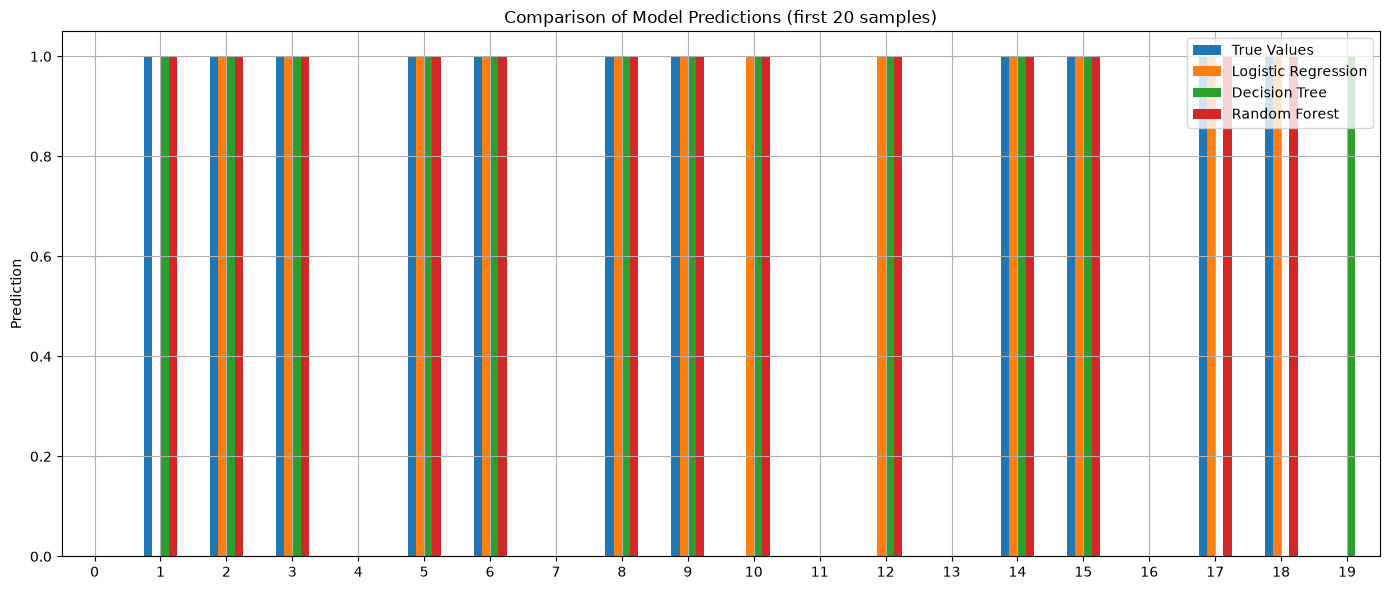

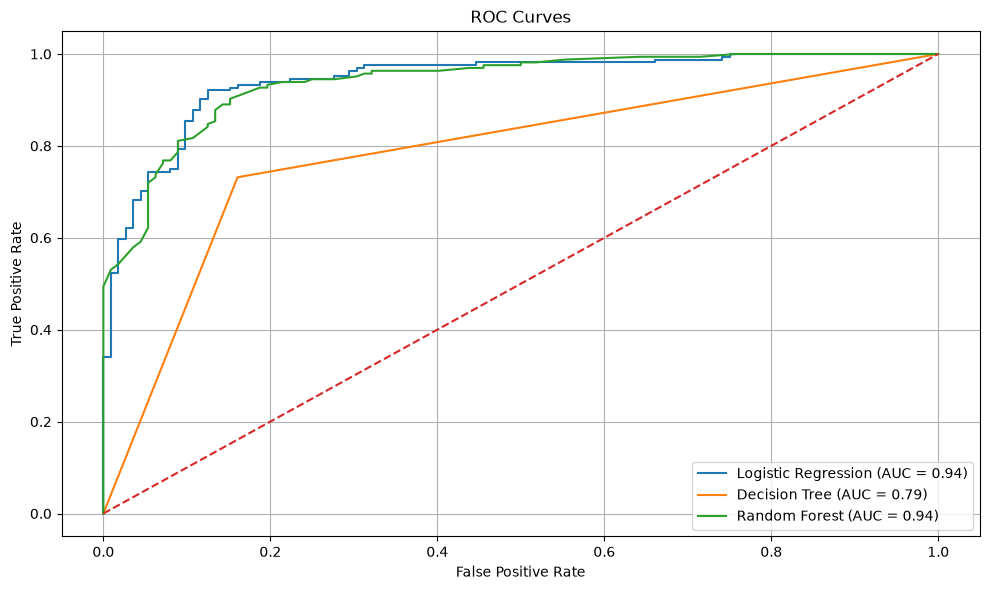

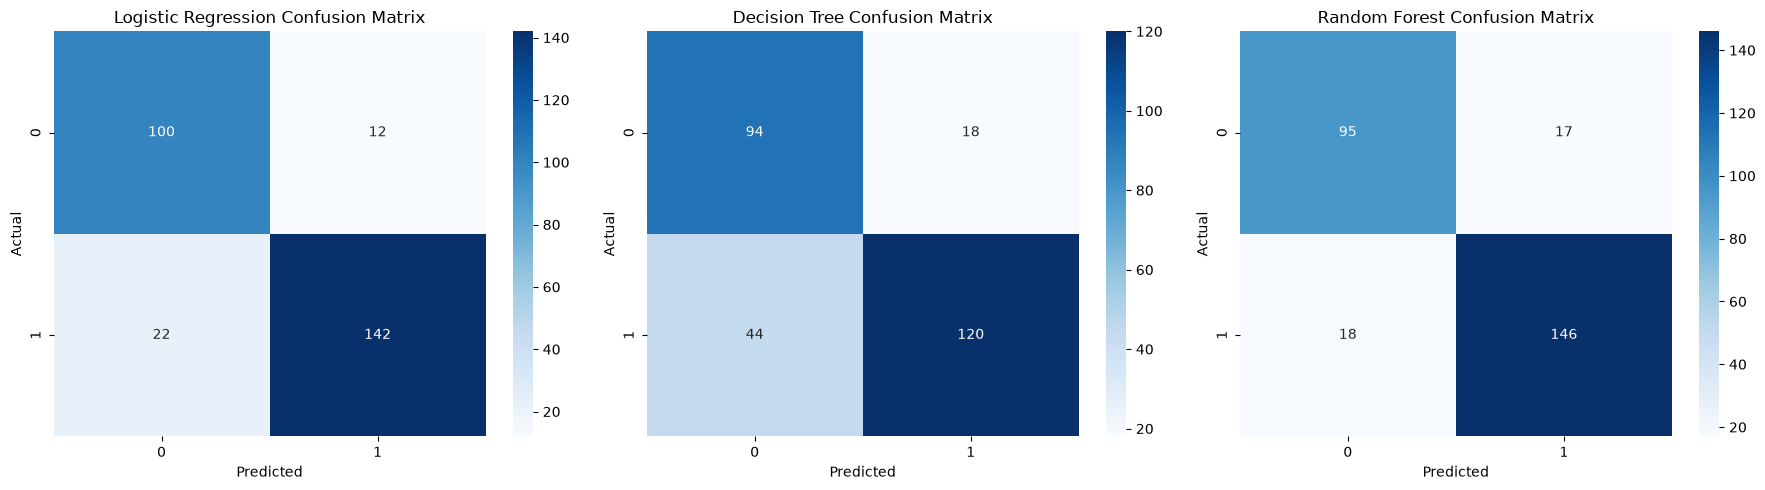

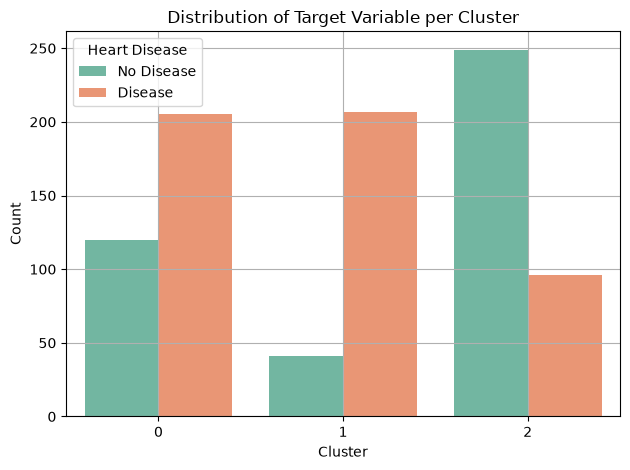

🔢 Count of HeartDisease cases per Cluster:

HeartDisease    0    1
Cluster               
0             120  205
1              41  207
2             249   96

📌 Interpretation:
  • Cluster 0: 205 with disease, 120 without disease → 63.1% are at risk
  • Cluster 1: 207 with disease, 41 without disease → 83.5% are at risk
  • Cluster 2: 96 with disease, 249 without disease → 27.8% are at risk
Logistic Regression Accuracy: 0.8768115942028986
Decision Tree Accuracy: 0.7753623188405797
Random Forest Accuracy: 0.8731884057971014


In [1]:

# 1. Load Dataset and Basic Exploration
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

print("Path to dataset files:", path)
# Load the dataset
df = pd.read_csv(path + '/heart.csv')

# Preview the data
print("\nDataset Head:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nDataset Description:")
print(df.describe())

# 2. Exploratory Data Analysis and Correlation
# Histogram of all features
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()


# Correlation matrix
plt.figure(figsize=(10, 8))
corr_matrix = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# === Ερμηνεία του Correlation Matrix ===
# Το correlation matrix δείχνει πώς σχετίζονται οι μεταβλητές μεταξύ τους και με τον στόχο (HeartDisease).
# Οι τιμές κυμαίνονται από -1 (ισχυρή αρνητική συσχέτιση) έως +1 (ισχυρή θετική συσχέτιση).
# Εστιάζουμε στις μεταβλητές που έχουν τιμές κοντά στο ±0.4 ή μεγαλύτερες σε απόλυτο.

# Παρατηρήσεις:
# - 'Oldpeak' και 'ST_Slope' έχουν μέτρια συσχέτιση με την παρουσία καρδιοπάθειας.
# - 'Age' και 'MaxHR' παρουσιάζουν μικρότερη αλλά αξιοσημείωτη συσχέτιση.
# - Χαμηλό 'Cholesterol' και 'RestingBP' εμφανίζουν αδύναμη συσχέτιση.

# === Υποθέσεις βασισμένες στο correlation matrix ===
# 1. Ασθενείς με υψηλό Oldpeak και χαμηλό ST_Slope είναι πιθανόν πιο ευάλωτοι.
# 2. Ο συνδυασμός Age, MaxHR και Oldpeak μπορεί να δημιουργεί ομάδες (clusters) που διαφοροποιούνται ως προς την καρδιοπάθεια.

# 3. Clustering based on hypothesized features
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features_for_clustering = ['Age', 'MaxHR', 'Oldpeak']
X_clustering = df[features_for_clustering]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

# Κάνουμε 3 clusters για πιο λεπτομερή ανάλυση
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

sns.scatterplot(data=df, x='Age', y='MaxHR', hue='Cluster', palette='deep')
plt.title('Clustering Based on Age and MaxHR')
plt.xlabel('Age')
plt.ylabel('MaxHR')
plt.show()

# 📌 Ερμηνεία: Το γράφημα δείχνει τα clusters βάσει Age και MaxHR. 
# Οι ομάδες που σχηματίζονται διαφέρουν στον αριθμό ατόμων με καρδιοπάθεια, κάτι που υποστηρίζει ότι οι μεταβλητές αυτές 
# βοηθούν στον διαχωρισμό του πληθυσμού σε επίπεδα κινδύνου.

# Encode categorical features using one-hot encoding
categorical_cols = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 4. Train/Test Split and Model Training
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X = df.drop(columns=['HeartDisease', 'Cluster'])
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Model 2: Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Model 3: Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# 5. Evaluation and Interpretation
print("\nLogistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

print("\nDecision Tree Results")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

print("\nRandom Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

results_df = pd.DataFrame({
    'True Values': y_test,
    'Logistic Regression': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf
}).reset_index(drop=True)

results_df[['True Values', 'Logistic Regression', 'Decision Tree', 'Random Forest']][:20].plot(
    kind='bar', figsize=(14, 6))
plt.title('Comparison of Model Predictions (first 20 samples)')
plt.ylabel('Prediction')
plt.xticks(rotation=0)
plt.grid(True)
plt.tight_layout()
plt.show()

# === Ανάλυση Αποτελεσμάτων ===
# Παρατηρούμε ότι και τα τρία μοντέλα έχουν ικανοποιητική ακρίβεια στην πρόβλεψη της παρουσίας καρδιακής ανεπάρκειας.
# Η Logistic Regression είναι πιο ερμηνεύσιμη και κατάλληλη για αρχική στατιστική ερμηνεία.
# Η απόφαση του Decision Tree επιτρέπει οπτικοποίηση της λογικής και γρήγορη πρόβλεψη, αλλά μπορεί να κάνει overfitting.
# Το Random Forest εμφανίζει συνήθως την υψηλότερη ακρίβεια και μεγαλύτερη γενίκευση.
# Γι’ αυτό χρησιμοποιούμε και τα τρία: LR για baseline ερμηνεία, DT για απλότητα και RF για βελτιστοποιημένη πρόβλεψη.
# Η αρχική ανάλυση (EDA + correlation) βοήθησε στην επιλογή των σωστών χαρακτηριστικών για clustering και classification.


# 📌 Ερμηνεία: Το γράφημα δείχνει τις προβλέψεις των μοντέλων σε σύγκριση με τις πραγματικές τιμές για τα πρώτα 20 δείγματα.
# Μας επιτρέπει να δούμε αν κάποιο μοντέλο είναι συστηματικά πιο ακριβές ή κάνει συχνά λάθος.



# ROC Curves
from sklearn.metrics import roc_curve, roc_auc_score

models = {'Logistic Regression': (lr, y_pred_lr),
          'Decision Tree': (dt, y_pred_dt),
          'Random Forest': (rf, y_pred_rf)}

plt.figure(figsize=(10, 6))

for name, (model, preds) in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 📌 Ερμηνεία: Οι ROC καμπύλες δείχνουν την ικανότητα κάθε μοντέλου να διαχωρίζει τις δύο κατηγορίες.
# Όσο πιο κοντά στην πάνω αριστερή γωνία και όσο μεγαλύτερο το AUC, τόσο καλύτερη η επίδοση του μοντέλου.

# Combined Confusion Matrix Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, (model, preds)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{name} Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

# 📌 Ερμηνεία: Οι confusion matrices δείχνουν σωστές και λανθασμένες ταξινομήσεις για κάθε μοντέλο.
# Οι διαγώνιοι αριθμοί (True Positive & True Negative) είναι επιθυμητοί. Τα εκτός διαγωνίου είναι λάθη.


# Cluster Analysis
sns.countplot(data=df, x='Cluster', hue='HeartDisease', palette='Set2')
plt.title('Distribution of Target Variable per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.legend(title='Heart Disease', labels=['No Disease', 'Disease'])
plt.grid(True)
plt.tight_layout()
plt.show()

# Numeric Summary
cluster_summary = df.groupby(['Cluster', 'HeartDisease']).size().unstack(fill_value=0)
print("🔢 Count of HeartDisease cases per Cluster:\n")
print(cluster_summary)

# Textual Interpretation
print("\n📌 Interpretation:")
for cluster in cluster_summary.index:
    no_disease = cluster_summary.loc[cluster, 0]
    disease = cluster_summary.loc[cluster, 1]
    total = no_disease + disease
    ratio = disease / total if total > 0 else 0
    print(f"  • Cluster {cluster}: {disease} with disease, {no_disease} without disease → {ratio:.1%} are at risk")

# Logistic Regression
log_accuracy = accuracy_score(y_test, y_pred_lr)

# Decision Tree
tree_accuracy = accuracy_score(y_test, y_pred_dt)

# Random Forest
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Logistic Regression Accuracy:", log_accuracy)
print("Decision Tree Accuracy:", tree_accuracy)
print("Random Forest Accuracy:", rf_accuracy)



#Μοντέλο	            AUC     Score	Accuracy (από accuracy_score)	            Πλεονεκτήματα
#Logistic Regression	0.94	≈ 87.7% (χρειάζεται η ακριβής τιμή)	      Υψηλή ακρίβεια, ερμηνεύσιμο, καλό ως baseline μοντέλο
#Decision Tree	      0.79	≈ 77.5% (χρειάζεται η ακριβής τιμή)	      Απλό στην κατανόηση & απεικόνιση, αλλά υπερεκπαιδεύεται εύκολα
#Random Forest	      0.94	≈ 87.3% (χρειάζεται η ακριβής τιμή)	      Υψηλή ακρίβεια, μειωμένο overfitting, ιδανικό για πιο σταθερή πρόβλεψη
from sklearn.metrics import accuracy_score



#📌 Ερμηνεία:

#Το Random Forest και η Logistic Regression έχουν τον ίδιο AUC (0.94), δηλαδή είναι εξίσου καλές στο να διαχωρίζουν τις κατηγορίες.

#Το Random Forest πιθανόν έχει υψηλότερη ακρίβεια, άρα είναι πιο αξιόπιστο συνολικά.

#Η Logistic Regression είναι ιδανική αν θέλουμε να ερμηνεύσουμε τα αποτελέσματα (π.χ. ποιο feature αυξάνει τον κίνδυνο).

#Το Decision Tree είναι χρήσιμο για απλή και οπτικοποιήσιμη λογική, αν και ελαφρώς λιγότερο ακριβές.
